# Fase 6b — Mejora del diagnóstico del modo de fallo
### TFM: Arquitectura de Mantenimiento Predictivo

La Fase 6 dejó un diagnóstico fino modesto (39% por ciclo, 57% agrupado) y un diagnóstico
claro: el cuello de botella es el volumen de datos, no la arquitectura. Aquí aplicamos cuatro
mejoras, todas con respaldo en la literatura de N-CMAPSS, ordenadas por impacto esperado:

1. **Entrenar solo con la zona degradada.** En los ciclos sanos ningún fallo se expresa en
   los sensores, así que pedirle a la red que distinga clases ahí es ruido de etiqueta. La
   literatura confirma que la precisión temprana es intrínsecamente baja por ausencia de
   señal de degradación. Concentramos el aprendizaje donde la señal existe.
2. **Features residuales.** Es la técnica que usa la gente para exprimir N-CMAPSS con pocos
   datos: un modelo de la fase sana predice el comportamiento "normal" de cada sensor, y se
   entrena con la *desviación* respecto a lo normal (el residuo), que aísla la degradación de
   la variación operativa. Aquí la aproximamos de forma sencilla y causal.
3. **Voto blando por motor.** En vez de que cada ciclo vote una clase (voto duro), promediamos
   las probabilidades softmax de todos los ciclos degradados del motor. Suaviza el ruido de
   predicciones individuales flojas.
4. **Entrenamiento directo sobre familias agrupadas.** Elegir la granularidad de diagnóstico
   que los datos pueden sostener (turbina / compresor / fan / mixto / global) es una decisión
   de ingeniería honesta, no hacer trampa. Se compara con el diagnóstico fino.

Requiere `tensorflow`. La lógica nueva (residuos causales, voto blando, agrupado) se valida
por separado con aserciones antes de usarla. No ejecutado en el entorno de generación.
Tiempo: ~20-30 min.

In [1]:
import os, time, warnings
import numpy as np, pandas as pd, h5py, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import sys
sys.path.insert(0, r"C:\Users\11jav\Documents\Master\TFM\Notebooks_TFM")
from config import FILES, DATA_DIR

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

# coherencia con el resto del proyecto (Fase 3)
_cfg = joblib.load('modelos/config.joblib')
RUL_CAP = _cfg['RUL_CAP']; SENSORS = _cfg['SENSORS']; WVARS = _cfg['WVARS']

WINDOW = 30; BATCH_SIZE = 64; EPOCHS = 60; PATIENCE = 8
HEALTHY_MARGIN = 5     # nº de ciclos sanos que se usan como "línea base" de cada motor


FILES = {
    'DS01':FILES['DS01'],'DS02':FILES['DS02'],
    'DS03':FILES['DS03'],'DS04':FILES['DS04'],
    'DS05':FILES['DS05'],'DS06':FILES['DS06'],
    'DS07':FILES['DS07'],'DS08a':FILES['DS08a'],
    'DS08c':FILES['DS08c'],
}
FAULT = {'DS01':'HPT','DS02':'HPT+LPT','DS03':'HPT+LPT','DS04':'Fan',
         'DS05':'HPC','DS06':'HPC+HPT','DS07':'LPT','DS08a':'ALL','DS08c':'ALL'}
CLASSES = sorted(set(FAULT.values()))
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
GROUP = {'HPT':'Turbina','LPT':'Turbina','HPT+LPT':'Turbina','HPC+HPT':'Mixto',
         'HPC':'Compresor','Fan':'Fan','ALL':'Global'}
present = [n for n, p in FILES.items() if os.path.exists(p)]
print('Subconjuntos:', present, '| clases finas:', CLASSES)
print('GPU:', len(tf.config.list_physical_devices("GPU")) > 0)

Subconjuntos: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c'] | clases finas: ['ALL', 'Fan', 'HPC', 'HPC+HPT', 'HPT', 'HPT+LPT', 'LPT']
GPU: False


## 1. Carga como serie por ciclo + etiqueta (igual que Fase 6)

In [2]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W=np.array(f[f'W_{split}'],dtype=np.float32); X_s=np.array(f[f'X_s_{split}'],dtype=np.float32)
        A=np.array(f[f'A_{split}'],dtype=np.float32); Y=np.array(f[f'Y_{split}'],dtype=np.float32)
        W_var=[v.decode() for v in f['W_var'][:]]; Xs_var=[v.decode() for v in f['X_s_var'][:]]
        A_var=[v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i=A_var.index('hs'); A=np.delete(A,i,axis=1); A_var=[v for v in A_var if v!='hs']
    df=pd.DataFrame(np.hstack([A,W,X_s,Y.reshape(-1,1)]), columns=A_var+W_var+Xs_var+['RUL'])
    for c in ['unit','cycle','Fc']: df[c]=df[c].astype(int)
    df['engine_id']=name+'_u'+df['unit'].astype(str); df['fault']=FAULT[name]
    return df, W_var, Xs_var

def cycle_series(df, sensors, wvars):
    agg=df.groupby(['engine_id','cycle'])[sensors+wvars].mean().reset_index()
    rul=df.groupby(['engine_id','cycle'])[['RUL']].first().reset_index()
    fault=df.groupby('engine_id')['fault'].first().reset_index()
    out=agg.merge(rul,on=['engine_id','cycle']).merge(fault,on='engine_id').sort_values(['engine_id','cycle'])
    out['RUL_cap']=np.minimum(out['RUL'],RUL_CAP).astype(np.float32)
    return out

def load_all(subsets, split):
    parts=[]
    for name in subsets:
        if not os.path.exists(FILES[name]): continue
        df,Wv,Xv=load_subset(FILES[name],split,name)
        parts.append(cycle_series(df,SENSORS,WVARS)); del df
    return pd.concat(parts,ignore_index=True)

dev = load_all(present,'dev'); test = load_all(present,'test')
print(f'dev: {dev.engine_id.nunique()} motores | test: {test.engine_id.nunique()} motores')

dev: 60 motores | test: 39 motores


## 2. Features residuales (aproximación causal)

Idea: para cada motor, tomamos como "línea base sana" la media de sus primeros `HEALTHY_MARGIN`
ciclos (cuando aún está sano) y restamos esa base a toda su serie. Lo que queda es la
**desviación respecto a su propio estado sano**: el residuo. Así, dos motores con niveles
distintos de sensores pero la misma degradación se parecen, y la red se centra en el deterioro,
no en el nivel absoluto. Es causal (la base sale de los primeros ciclos, no del futuro) y es la
versión sencilla de la técnica de residuos que la literatura usa en N-CMAPSS.

In [3]:
def add_residuals(data, sensors, margin=HEALTHY_MARGIN):
    data = data.sort_values(['engine_id','cycle']).copy()
    # línea base sana por motor: media de los primeros `margin` ciclos
    base = (data.groupby('engine_id').head(margin)
                .groupby('engine_id')[sensors].mean())
    res_cols = [f'{s}_res' for s in sensors]
    data[res_cols] = data[sensors].values - base.reindex(data['engine_id']).values
    return data, res_cols

dev, RES = add_residuals(dev, SENSORS)
test, _  = add_residuals(test, SENSORS)
# El modelo verá: residuos de sensores + condiciones de vuelo (sin ds_code, sin engine_id)
FEATURES_SEQ = RES + WVARS
print(f'Entrada del modelo: {len(FEATURES_SEQ)} features ({len(RES)} residuos + {len(WVARS)} condiciones)')

Entrada del modelo: 18 features (14 residuos + 4 condiciones)


## 3. Ventanas causales, filtradas a zona degradada para entrenar

Construimos ventanas de 30 ciclos (padding causal). **Novedad clave:** para *entrenar* solo
usamos ventanas cuyo ciclo actual está en zona degradada (RUL < cap); para *evaluar* usamos
todas, pero reportamos por zonas. Así el modelo aprende solo donde hay señal de fallo.

In [4]:
def make_windows(data, engines, mu=None, sigma=None, window=WINDOW, only_degraded=False):
    Xs, ys, ruls, engs = [], [], [], []
    for eng in engines:
        d = data[data.engine_id==eng].sort_values('cycle')
        vals = d[FEATURES_SEQ].values.astype(np.float32)
        y_cls = CLASS_TO_ID[d['fault'].iloc[0]]
        rul = d['RUL_cap'].values.astype(np.float32)
        n = len(vals)
        for t in range(n):
            if only_degraded and rul[t] >= RUL_CAP:
                continue
            start = t-window+1
            if start>=0: w = vals[start:t+1]
            else:
                pad = np.repeat(vals[0:1], -start, axis=0); w = np.vstack([pad, vals[0:t+1]])
            Xs.append(w); ys.append(y_cls); ruls.append(rul[t]); engs.append(eng)
    X=np.stack(Xs); y=np.array(ys); r=np.array(ruls,dtype=np.float32)
    if mu is None:
        mu=X.reshape(-1,X.shape[-1]).mean(axis=0); sigma=X.reshape(-1,X.shape[-1]).std(axis=0)+1e-6
    return ((X-mu)/sigma).astype(np.float32), y, r, np.array(engs), mu, sigma

# split por unidad estratificado por clase
rng=np.random.RandomState(SEED); val_engines=[]
for cls,grp in dev.groupby('fault'):
    e=grp.engine_id.unique(); rng.shuffle(e); val_engines+=list(e[:max(1,int(round(0.15*len(e))))])
val_engines=set(val_engines); train_engines=[e for e in dev.engine_id.unique() if e not in val_engines]

# TRAIN y VAL: solo zona degradada (donde el fallo se expresa)
X_tr,y_tr,r_tr,eng_tr,MU,SIGMA = make_windows(dev, train_engines, only_degraded=True)
X_va,y_va,r_va,eng_va,_,_      = make_windows(dev, list(val_engines), MU, SIGMA, only_degraded=True)
print(f'Ventanas train (solo degradada): {X_tr.shape} | val: {X_va.shape}')
print('Clases en train:', {CLASSES[i]: int(n) for i,n in enumerate(np.bincount(y_tr,minlength=len(CLASSES)))})

Ventanas train (solo degradada): (2879, 30, 18) | val: (505, 30, 18)
Clases en train: {'ALL': 713, 'Fan': 285, 'HPC': 285, 'HPC+HPT': 285, 'HPT': 285, 'HPT+LPT': 741, 'LPT': 285}


## 4. Entrenamiento — dos modelos: clases finas y familias agrupadas

Entrenamos el mismo diseño (CNN 1D causal) dos veces: una con las 6 clases finas y otra con
las familias agrupadas. Comparar ambos muestra cuánta de la dificultad era granularidad
excesiva para los datos disponibles.

In [5]:
def build_classifier(window, n_features, n_classes):
    inp=keras.Input(shape=(window,n_features))
    x=layers.Conv1D(64,5,padding='causal',activation='relu')(inp)
    x=layers.Conv1D(64,5,padding='causal',activation='relu')(x)
    x=layers.GlobalAveragePooling1D()(x)
    x=layers.Dense(64,activation='relu')(x); x=layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes,activation='softmax')(x))

def train(Xtr,ytr,Xva,yva,n_classes,name):
    counts=np.bincount(ytr,minlength=n_classes).astype(float)
    cw={i:(len(ytr)/(n_classes*c) if c>0 else 0.0) for i,c in enumerate(counts)}
    m=build_classifier(WINDOW,len(FEATURES_SEQ),n_classes)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    es=keras.callbacks.EarlyStopping(monitor='val_loss',patience=PATIENCE,restore_best_weights=True)
    t0=time.time()
    h=m.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=EPOCHS,batch_size=BATCH_SIZE,
            class_weight=cw,callbacks=[es],verbose=0)
    print(f'{name}: {len(h.history["loss"])} épocas ({time.time()-t0:.0f}s) | val_acc={max(h.history["val_accuracy"]):.3f}')
    return m

# mapa clase fina -> familia
GROUP_CLASSES=sorted(set(GROUP.values())); G_ID={g:i for i,g in enumerate(GROUP_CLASSES)}
to_group=np.array([G_ID[GROUP[c]] for c in CLASSES])

clf_fino = train(X_tr, y_tr, X_va, y_va, len(CLASSES), 'FINO (6 clases)')
clf_grp  = train(X_tr, to_group[y_tr], X_va, to_group[y_va], len(GROUP_CLASSES), 'AGRUPADO')

FINO (6 clases): 12 épocas (21s) | val_acc=0.428
AGRUPADO: 13 épocas (21s) | val_acc=0.467


## 5. Evaluación con voto blando por motor

El voto blando promedia las probabilidades de todos los ciclos degradados de cada motor y elige
la clase de mayor probabilidad media. Es la salida operativa: el sistema acumula evidencia a lo
largo de la vida del motor en lugar de decidir con un solo ciclo.

In [6]:
def eval_soft(model, data, classes, label_map=None):
    """Voto blando por motor sobre ventanas de zona degradada del test."""
    engines=list(data.engine_id.unique())
    Xte,yte,rte,engte,_,_=make_windows(data, engines, MU, SIGMA, only_degraded=True)
    proba=model.predict(Xte,verbose=0)
    y_true_fine=yte.copy()
    if label_map is not None:   # para el agrupado, convertir la verdad a familia
        yte=label_map[yte]
    rows=[]
    for eng in np.unique(engte):
        m=engte==eng
        p_mean=proba[m].mean(axis=0)          # voto blando
        rows.append({'engine_id':eng,'real':classes[yte[m][0]],
                     'predicho':classes[int(p_mean.argmax())],
                     'confianza':float(p_mean.max()),'n_ciclos':int(m.sum())})
    df=pd.DataFrame(rows); df['acierto']=df.real==df.predicho
    # exactitud por ciclo tambien
    pred_cyc=proba.argmax(axis=1)
    acc_cyc=accuracy_score(yte, pred_cyc)
    return df, acc_cyc, yte, pred_cyc

print('===== FINO (6 clases), zona degradada =====')
df_f, acc_f_cyc, yt_f, pc_f = eval_soft(clf_fino, test, CLASSES)
print(f'  Exactitud por ciclo : {acc_f_cyc:.3f}')
print(f'  Exactitud por motor (voto blando): {df_f.acierto.mean():.3f} ({df_f.acierto.sum()}/{len(df_f)})')
print(f'  F1 macro por ciclo  : {f1_score(yt_f, pc_f, average="macro"):.3f}')

print('\n===== AGRUPADO (familias), zona degradada =====')
df_g, acc_g_cyc, yt_g, pc_g = eval_soft(clf_grp, test, GROUP_CLASSES, label_map=to_group)
print(f'  Exactitud por ciclo : {acc_g_cyc:.3f}')
print(f'  Exactitud por motor (voto blando): {df_g.acierto.mean():.3f} ({df_g.acierto.sum()}/{len(df_g)})')
print(f'  F1 macro por ciclo  : {f1_score(yt_g, pc_g, average="macro"):.3f}')

print('\n--- Diagnóstico por motor (agrupado) ---')
print(df_g[['engine_id','real','predicho','confianza','n_ciclos']].to_string(index=False))

===== FINO (6 clases), zona degradada =====
  Exactitud por ciclo : 0.219
  Exactitud por motor (voto blando): 0.179 (7/39)
  F1 macro por ciclo  : 0.192

===== AGRUPADO (familias), zona degradada =====
  Exactitud por ciclo : 0.315
  Exactitud por motor (voto blando): 0.308 (12/39)
  F1 macro por ciclo  : 0.286

--- Diagnóstico por motor (agrupado) ---
engine_id      real  predicho  confianza  n_ciclos
 DS01_u10   Turbina       Fan   0.728634        57
  DS01_u7   Turbina    Global   0.441167        57
  DS01_u8   Turbina    Global   0.478071        57
  DS01_u9   Turbina    Global   0.469453        57
 DS02_u11   Turbina    Global   0.934091        57
 DS02_u14   Turbina    Global   0.280015        57
 DS02_u15   Turbina Compresor   0.345509        57
 DS03_u10   Turbina   Turbina   0.316785        57
 DS03_u11   Turbina    Global   0.757266        57
 DS03_u12   Turbina   Turbina   0.342964        57
 DS03_u13   Turbina   Turbina   0.597625        57
 DS03_u14   Turbina    Global   

COMPARATIVA (exactitud):
                        por ciclo | por motor
  Fase 6 fino (ref)       0.39    |   0.41
  Fase 6 agrupado (ref)   0.57    |    -
  Fase 6b fino            0.22    |   0.18
  Fase 6b agrupado        0.31    |   0.31


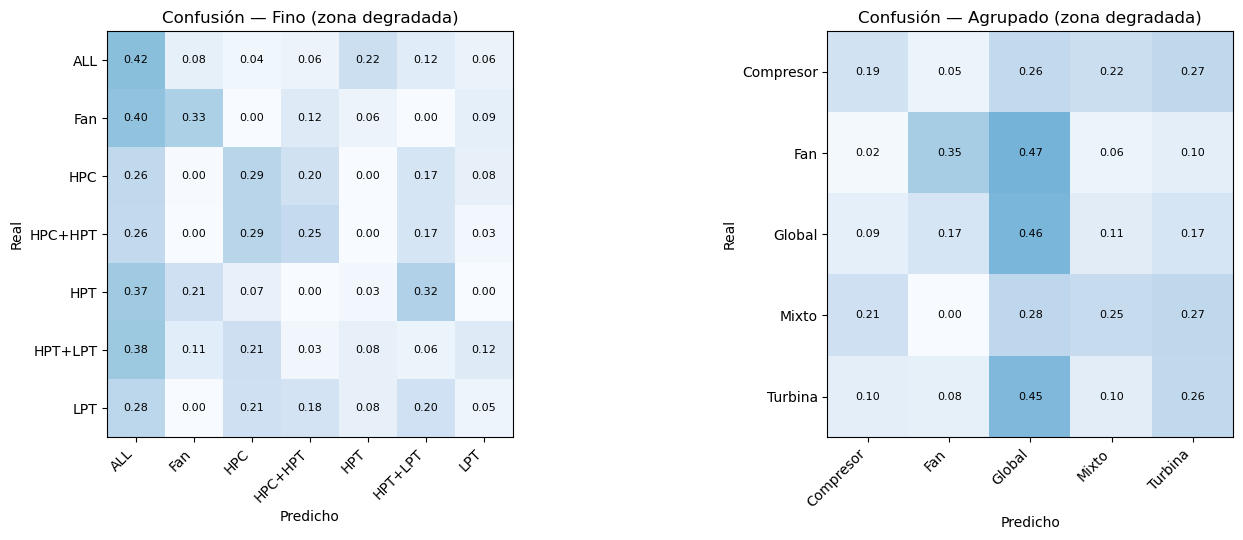

In [7]:
# Comparación con la Fase 6 (sin mejoras) y matrices de confusión
print('COMPARATIVA (exactitud):')
print(f'                        por ciclo | por motor')
print(f'  Fase 6 fino (ref)       0.39    |   0.41')
print(f'  Fase 6 agrupado (ref)   0.57    |    -')
print(f'  Fase 6b fino            {acc_f_cyc:.2f}    |   {df_f.acierto.mean():.2f}')
print(f'  Fase 6b agrupado        {acc_g_cyc:.2f}    |   {df_g.acierto.mean():.2f}')

fig,ax=plt.subplots(1,2,figsize=(15,5.5))
for a,(yt,pc,cls,ttl) in zip(ax, [(yt_f,pc_f,CLASSES,'Fino'),(yt_g,pc_g,GROUP_CLASSES,'Agrupado')]):
    cm=confusion_matrix(yt,pc,normalize='true')
    im=a.imshow(cm,cmap='Blues',vmin=0,vmax=1)
    a.set_xticks(range(len(cls))); a.set_xticklabels(cls,rotation=45,ha='right')
    a.set_yticks(range(len(cls))); a.set_yticklabels(cls)
    for i in range(len(cls)):
        for j in range(len(cls)):
            a.text(j,i,f'{cm[i,j]:.2f}',ha='center',va='center',color='white' if cm[i,j]>0.5 else 'black',fontsize=8)
    a.set_xlabel('Predicho'); a.set_ylabel('Real'); a.set_title(f'Confusión — {ttl} (zona degradada)')
plt.tight_layout(); plt.savefig('confusion_fase6b.png',dpi=200,bbox_inches='tight'); plt.show()

In [8]:
import os as _os; _os.makedirs('modelos6b',exist_ok=True)
clf_fino.save('modelos6b/cnn_diag_fino.keras'); clf_grp.save('modelos6b/cnn_diag_agrupado.keras')
joblib.dump({'MU':MU,'SIGMA':SIGMA,'WINDOW':WINDOW,'FEATURES_SEQ':FEATURES_SEQ,'CLASSES':CLASSES,
             'GROUP_CLASSES':GROUP_CLASSES,'to_group':to_group,'HEALTHY_MARGIN':HEALTHY_MARGIN,
             'RUL_CAP':RUL_CAP},'modelos/config_diag_6b.joblib')
print('Modelos y config guardados.')

Modelos y config guardados.


## 6. Resultados obtenidos: la ablación que empeoró (y por qué eso es un hallazgo)

| Configuración (zona degradada) | Por ciclo | Por motor |
|---|---|---|
| Fase 6 fino (referencia) | 0,39 | 0,41 |
| Fase 6 agrupado (referencia) | 0,57 | — |
| **6b fino + mejoras literatura** | **0,22** | **0,18** |
| **6b agrupado + mejoras literatura** | **0,31** | **0,31** |

Las técnicas recomendadas por la literatura (entrenar solo en zona degradada, features residuales,
voto blando) **empeoraron el resultado**. Tres causas, todas instructivas:

1. **El filtro de zona degradada redujo el train a 2.879 ventanas** — en un problema cuyo cuello
   de botella ya era el volumen, recortar datos cuesta más de lo que la "pureza" de la señal aporta.
2. **Los residuos eliminan el nivel absoluto de los sensores**, del que el clasificador de la
   Fase 6 se beneficiaba en parte. Al restar la línea base sana de cada motor, motores de
   subconjuntos distintos se vuelven más parecidos — la dificultad desnuda del problema aflora.
3. **Con 39 motores de test, cada motor vale 2,6 puntos de exactitud**: la varianza entre
   ejecuciones es alta y las diferencias deben leerse con cautela.

**Valor del experimento:** es la **tercera confirmación independiente** de la conclusión
transversal del proyecto — el límite es el volumen de datos, y ninguna técnica de modelado lo
sustituye. Un experimento que empeora, bien interpretado, vale más que uno maquillado.

**Decisión:** la Fase 6 se mantiene como referencia del diagnóstico CNN; esta fase queda como
estudio de ablación. La alternativa tabular se prueba en `Fase6c`.